In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("fighters_cleaned.csv")
df.head()

,Fighter_Name,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Height_in,Reach_in,Weight_lbs,Ape_Index,Weight_Class
0,Nariman Abbasov,Orthodox,1994-02-01,28,4,0,3.00,0.20,5.67,0.46,0.00,0.00,0.66,0.0,68,66.0,155.0,-2.0,Lightweight
1,Darion Abbey,Orthodox,1993-02-25,9,5,0,8.44,0.50,14.06,0.28,0.00,0.00,0.00,0.0,74,80.0,265.0,6.0,Heavyweight
2,Hamdy Abdelwahab,Southpaw,1993-01-22,7,1,0,4.27,0.55,3.67,0.51,3.25,0.65,1.00,0.0,74,72.0,265.0,-2.0,Heavyweight
3,Mansur Abdul-Malik,Orthodox,1997-10-07,9,0,1,4.18,0.48,3.46,0.51,0.94,0.50,0.83,0.5,74,80.0,185.0,6.0,Middleweight
4,Shamil Abdurakhimov,Orthodox,1981-09-02,20,8,0,2.41,0.44,3.02,0.55,1.01,0.23,0.45,0.1,75,76.0,235.0,1.0,Heavyweight


## Selecting clustering features

In [9]:
# selecting clustering features
cluster_features = ["SLpM", "Str_Acc", "SApM", "Str_Def", 
                    "TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg", "Ape_Index"]

X = df[cluster_features].dropna()
print(X.shape)

(2514, 9)


## Scaling Features

In [11]:
# scaling features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.mean(axis=0).round(2))  # should all be ~0.0
print(X_scaled.std(axis=0).round(2))   # should all be ~1.0

[ 0.  0.  0. -0.  0.  0.  0.  0. -0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Elbow method to find k (where the line bends)

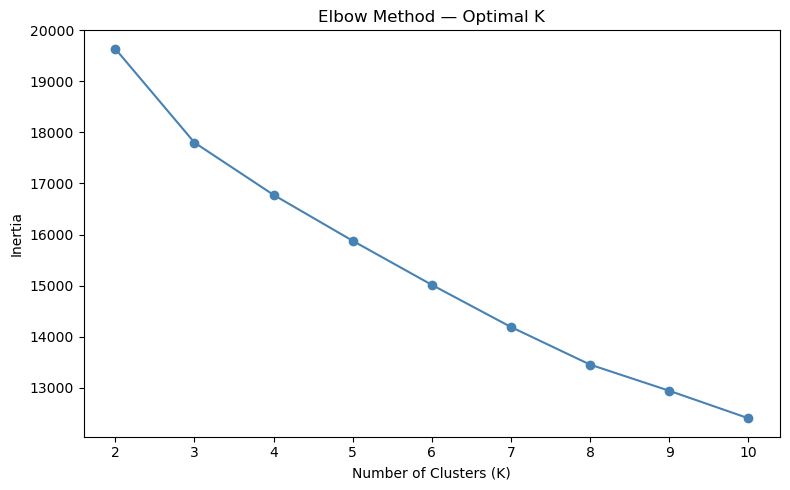

In [13]:
# elbow method to find k (where the line bends)
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color="steelblue")
plt.title("Elbow Method — Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## Fitting Kmeans model to 4

In [15]:
# fitting kmeans model to 4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
3    1074
0     645
2     425
1     370
Name: count, dtype: int64


## Avg Stats per cluster

In [17]:
# average stats per cluster
df.groupby("Cluster")[cluster_features].mean().round(2)

,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Ape_Index
Cluster,,,,,,,,,
0,5.04,0.49,4.81,0.53,0.66,0.21,0.66,0.26,0.95
1,2.64,0.49,2.78,0.50,3.88,0.49,0.40,1.56,1.50
2,2.23,0.35,5.10,0.40,0.43,0.08,0.21,0.34,1.59
3,3.17,0.44,3.16,0.56,1.68,0.45,0.65,0.45,2.21


## Styles found
0. High SLpM & High SApM: **Brawler** (throws and gets hit a lot)
1. Highest TD_Avg & Highest Sub_Avg: **Grappler** (takedowns and submissions)
2. Lowest SLpM & Lowest Str_Acc & Low everthing: **Defensive** (hard to hit, not much else)
3. Most Balanced Stats & Highest Ape_Index: **Balanced**

In [19]:
# mapping styles ive noticed
style_map = {0: "Brawler", 1: "Grappler", 2: "Defensive", 3: "Balanced"}
df["Fighting_Style"] = df["Cluster"].map(style_map)

print(df["Fighting_Style"].value_counts())

Fighting_Style
Balanced     1074
Brawler       645
Defensive     425
Grappler      370
Name: count, dtype: int64


## Radar/Spider Charts

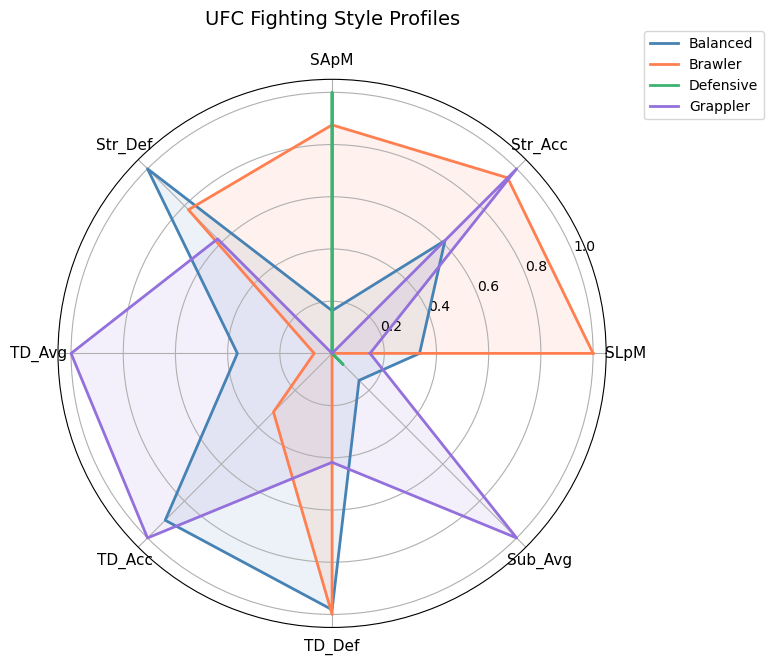

In [23]:
# radar/spider chart
import numpy as np

categories = ["SLpM", "Str_Acc", "SApM", "Str_Def", 
              "TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg"]

cluster_means = df.groupby("Fighting_Style")[categories].mean()

# Normalize each stat to 0-1 so they're comparable on the radar
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

styles = cluster_means_norm.index.tolist()
colors = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, style in enumerate(styles):
    values = cluster_means_norm.loc[style].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=style)
    ax.fill(angles, values, color=colors[i], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_title("UFC Fighting Style Profiles", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

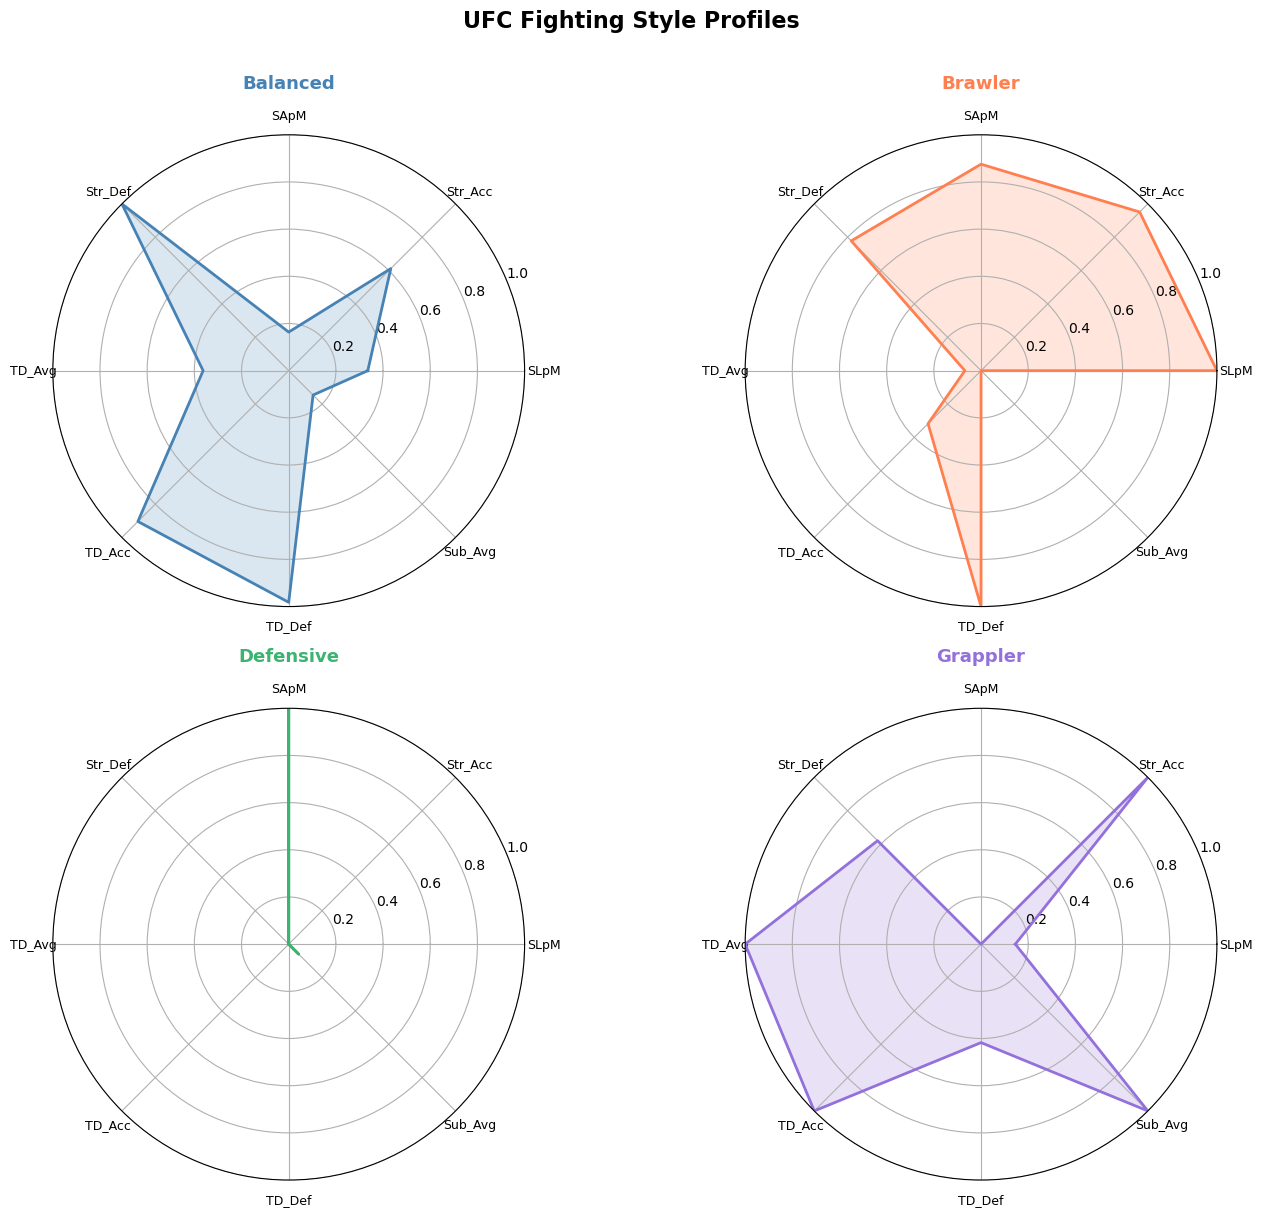

In [25]:
# radar plot for each style
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, style in enumerate(styles):
    ax = axes[i]
    values = cluster_means_norm.loc[style].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_title(style, size=13, pad=15, fontweight="bold", color=colors[i])
    ax.set_ylim(0, 1)

plt.suptitle("UFC Fighting Style Profiles", size=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Fighing style by weightclass

In [27]:
division_order = [
    "Flyweight", "Bantamweight", "Featherweight", "Lightweight",
    "Welterweight", "Middleweight", "Light Heavyweight", "Heavyweight"
]

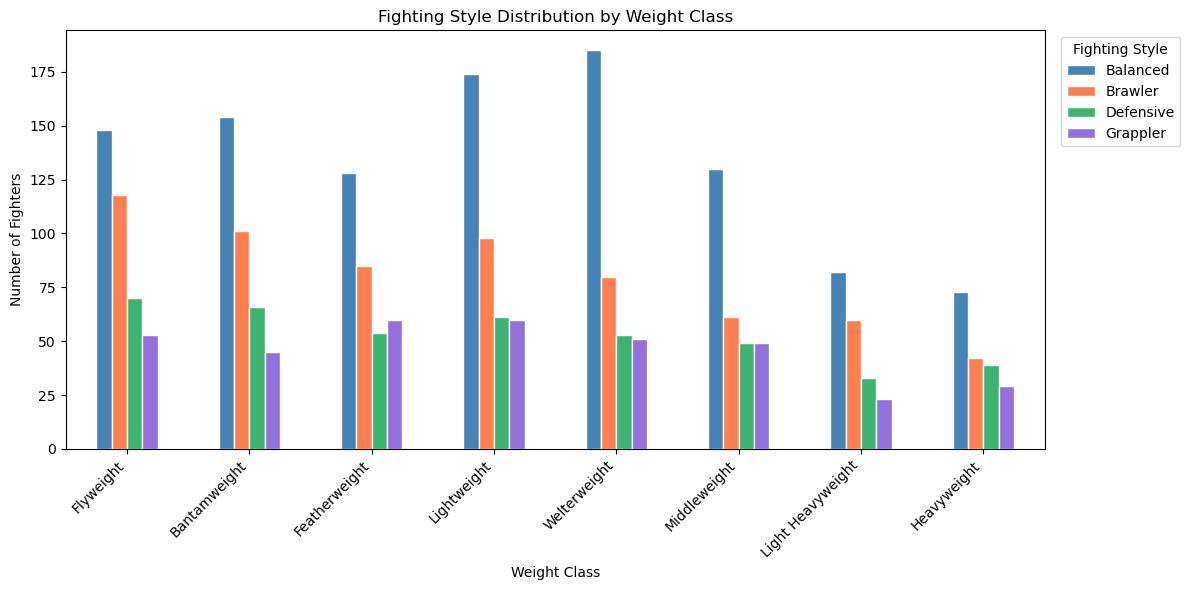

In [29]:
# fighting style by weight class
style_by_class = df.groupby(["Weight_Class", "Fighting_Style"]).size().unstack(fill_value=0)
style_by_class = style_by_class.reindex(division_order)

style_by_class.plot(kind="bar", figsize=(12, 6), 
                    color=["steelblue", "coral", "mediumseagreen", "mediumpurple"],
                    edgecolor="white")

plt.title("Fighting Style Distribution by Weight Class")
plt.xlabel("Weight Class")
plt.ylabel("Number of Fighters")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Fighting Style", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
df.to_csv("fighter_styles_clean.csv", index=False)
print("Saved!")

Saved!
